In [1]:
# === Cell 1: Setup & activate last run ===

import importlib
import numpy as np

import infra
import embeddings

importlib.reload(infra)
importlib.reload(embeddings)

# Activate last run explicitly (strict: errors if none)
infra.activate_last_run(echo=False)

# Load config + encoder spec for the active run (does not create a new run)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

# Reproducibility (one place only)
SEED = 42
np.random.seed(SEED)

# Read run parameters from config (single source of truth)
YEAR = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("PROJECT_ROOT :", infra.PROJECT_ROOT)
print("RUNS_ROOT    :", infra.RUNS_ROOT)
print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("Exports      :", RP.exports)
print("Cache (run)  :", RP.cache)
print("Cache (glob) :", infra.GLOBAL_CACHE_ROOT)
print("YEAR         :", YEAR)
print("ONET_VERSION :", ONET_VERSION)
print("ENCODER_NAME :", ENCODER_NAME)
print("ENCODER_ID   :", ENCODER_SPEC.embedder_id())
print("SEED         :", SEED)


PROJECT_ROOT : /home/joc/code/geometry-of-work
RUNS_ROOT    : /home/joc/code/geometry-of-work/out/runs
RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Cache (run)  : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/cache
Cache (glob) : /home/joc/code/geometry-of-work/out/_cache
YEAR         : 2025
ONET_VERSION : 30_1
ENCODER_NAME : openai-3-large
ENCODER_ID   : openai:text-embedding-3-large?dim=3072
SEED         : 42


In [2]:
# === Cell 2a: Notebook init (imports + O*NET DB + load exports via RP.export_fp) ===

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

import onet
from infra import log

# O*NET DB handle (use active run config)
db = onet.get_db(version=ONET_VERSION)
infra.log("O*NET version:", db.version)

# Load exports from active run (via RunPaths API)
TASKS_FP = RP.export_fp("task_embeddings_polar_scaled.csv")
OCC_FP   = RP.export_fp("occupation_embeddings_polar_scaled.csv")

df_tasks = infra.read_csv_any(TASKS_FP)
df_occ   = infra.read_csv_any(OCC_FP)

log("RUN_TAG:", infra.RUN_TAG)
log("Loaded df_tasks:", df_tasks.shape)
log("Loaded df_occ  :", df_occ.shape)


• O*NET version: 30.1
• RUN_TAG: embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
• Loaded df_tasks: (17606, 17)
• Loaded df_occ  : (878, 13)


In [3]:
# === Cell 2b: Params ===
SCALE_PREFERENCE = ("LV", "IM") # din gamla preferens
TOP_K_DEFAULT = None  # UPPDATERING: None för att inkludera alla (tidigare 35); sätt till int om du vill begränsa
# Angular profile (von Mises KDE)
N_THETA_PROFILE = 720
VON_MISES_KAPPA = 16.0
THETA_GRID = np.linspace(0, 2 * np.pi, N_THETA_PROFILE, endpoint=False)
# kNN density/area
K_AREA = 8
# robust minmax percentiles
ROBUST_LO, ROBUST_HI = 5, 95

In [4]:
# === Cell 2c: Small helpers (math + normalization) ===

def robust_minmax_params(x, lo=ROBUST_LO, hi=ROBUST_HI):
    x = np.asarray(x, float)
    a, b = np.nanpercentile(x, [lo, hi])
    return float(a), float(b)

def apply_minmax_with_params(x, a, b):
    den = max(b - a, 1e-12)
    y = (np.asarray(x, float) - a) / den
    return np.clip(y, 0, 1)

def robust_minmax(x, lo=ROBUST_LO, hi=ROBUST_HI):
    a, b = robust_minmax_params(x, lo=lo, hi=hi)
    return apply_minmax_with_params(x, a, b)

def resultant_direction(theta, w):
    W = np.sum(w)
    if not np.isfinite(W) or W <= 0:
        return 0.0, 0.0
    X = np.sum(w * np.cos(theta))
    Y = np.sum(w * np.sin(theta))
    th = float(np.mod(np.arctan2(Y, X), 2 * np.pi))
    R = float(np.hypot(X, Y) / max(W, 1e-12))
    return th, R

def circular_kde(theta_samples, weights, theta_grid, kappa):
    W = np.nansum(weights)
    if not np.isfinite(W) or W <= 0:
        return np.zeros_like(theta_grid)
    dg = theta_grid[:, None] - theta_samples[None, :]
    K = np.exp(kappa * np.cos(dg))
    I = (K * weights[None, :]).sum(axis=1)
    m = np.nanmax(I)
    return I / m if np.isfinite(m) and m > 0 else np.zeros_like(theta_grid)


In [5]:
# === Cell 2d: Geometry + local density (from df_occ) ===

def prepare_occ_geometry(df_occ: pd.DataFrame):
    occ = df_occ[["onet_code", "xi", "chi"]].copy()
    xi = np.mod(occ["xi"].to_numpy(float), 2 * np.pi)
    chi = occ["chi"].to_numpy(float)

    x = chi * np.cos(xi)
    y = chi * np.sin(xi)
    coords = np.column_stack([x, y])

    nbrs = NearestNeighbors(n_neighbors=K_AREA + 1).fit(coords)
    dists, _ = nbrs.kneighbors(coords)
    r_k = dists[:, -1]

    area = (np.pi * np.maximum(r_k, 1e-12) ** 2) / K_AREA
    density = 1.0 / np.maximum(area, 1e-12)

    occ["xi"] = xi
    occ["area_kNN"] = area
    occ["density_kNN"] = density
    return occ

occ_geom = prepare_occ_geometry(df_occ)


In [6]:
# === Cell 2e: O*NET table → wide (via onet) ===

def load_onet_wide(table_basename: str):
    # Prefer domänmoduler där de finns (Skills/Abilities), annars fall tillbaka på onet.elements.wide
    if table_basename.lower() == "skills":
        wide, scale = onet.skills.wide(db, scale_preference=SCALE_PREFERENCE)
    elif table_basename.lower() == "abilities":
        wide, scale = onet.abilities.wide(db, scale_preference=SCALE_PREFERENCE)
    else:
        wide, scale = onet.elements.wide(db, table_basename, scale_preference=SCALE_PREFERENCE)

    # Normalisera kodkolumnens namn om needed
    if "onet_code" not in wide.columns and "O*NET-SOC Code" in wide.columns:
        wide = wide.rename(columns={"O*NET-SOC Code": "onet_code"})

    return wide, scale


In [7]:
# === Cell 2f: Compute overlay + exports (no plots) ===
def compute_onet_overlay(
    table_basename: str,
    label: str = "skill",
    top_k: int | None = TOP_K_DEFAULT,  # UPPDATERING: Tillåt None för alla
    names_include=None,
    occ_geom: pd.DataFrame | None = None,
):
    if occ_geom is None:
        occ_geom = prepare_occ_geometry(df_occ)
    wide, scale = load_onet_wide(table_basename)
    value_cols = [c for c in wide.columns if c != "onet_code"]
    occ = occ_geom.merge(wide, on="onet_code", how="left")
    occ[value_cols] = occ[value_cols].apply(pd.to_numeric, errors="coerce")
    non_empty = [c for c in value_cols if occ[c].notna().any()]
    if names_include:
        chosen = [c for c in names_include if c in occ.columns]
    else:
        if top_k is not None and top_k > 0:  # UPPDATERING: Behåll variansbaserad sortering om top_k anges
            var_rank = sorted(
                ((c, float(np.nanvar(occ[c].to_numpy(float)))) for c in non_empty),
                key=lambda t: t[1],
                reverse=True,
            )
            chosen = [c for c, _ in var_rank[:top_k]]
        else:  # UPPDATERING: Inkludera alla non_empty om top_k=None
            chosen = sorted(non_empty)  # Sortera alfabetiskt för konsistens
    if not chosen:
        raise RuntimeError(f"No {label}s selected from {table_basename} ({scale}).")
    xi_all = occ["xi"].to_numpy(float)
    density = occ["density_kNN"].to_numpy(float)
    peak_info = []
    profile_rows = []
    vals_by = {}
    J_by = {}
    for name in chosen:
        vals = occ[name].to_numpy(float)
        vals_by[name] = vals
        med = np.nanmedian(vals)
        w = np.clip(vals - med, 0.0, None)
        if not np.isfinite(w).any() or np.nanmax(w) <= 0:
            w = robust_minmax(vals)
        mask = np.isfinite(xi_all) & np.isfinite(w)
        th = xi_all[mask]
        ww = w[mask]
        theta_max, R = resultant_direction(th, ww)
        I = circular_kde(th, ww, THETA_GRID, VON_MISES_KAPPA)
        peak_info.append((theta_max, name, R, int(mask.sum()), float(np.nanmax(I) if I.size else 0.0)))
        profile_rows.extend(
            (name, float(phi), float(np.degrees(phi) % 360.0), float(i))
            for phi, i in zip(THETA_GRID, I)
        )
        J_by[name] = vals.astype(float) * density
    peak_info.sort(key=lambda t: t[0])
    chosen_sorted = [n for _, n, *__ in peak_info]
    prefix = f"{label}s_overlay__{table_basename}__{scale}"
    angles_df = pd.DataFrame(
        peak_info,
        columns=["theta_max_rad", label, "resultant_R", "n_used", "I_max_kde"],
    )
    angles_df["theta_max_deg"] = np.degrees(angles_df["theta_max_rad"]) % 360.0
    angles_df = angles_df[[label, "theta_max_rad", "theta_max_deg", "resultant_R", "I_max_kde", "n_used"]]
    (RP.exports / f"{prefix}__angle_rank.csv").write_text(angles_df.to_csv(index=False), encoding="utf-8")
    profile_df = pd.DataFrame(profile_rows, columns=[label, "theta_rad", "theta_deg", "intensity_norm01"])
    (RP.exports / f"{prefix}__angle_profile.csv").write_text(profile_df.to_csv(index=False), encoding="utf-8")
    all_vals = np.concatenate([vals_by[n].astype(float) for n in chosen_sorted])
    glob_lo, glob_hi = robust_minmax_params(all_vals)
    all_J = np.concatenate([J_by[n] for n in chosen_sorted])
    JG_lo, JG_hi = robust_minmax_params(all_J)
    scales_val = [("__GLOBAL__", glob_lo, glob_hi, int(np.count_nonzero(np.isfinite(all_vals))))]
    for n in chosen_sorted:
        lo, hi = robust_minmax_params(vals_by[n])
        scales_val.append((n, lo, hi, int(np.count_nonzero(np.isfinite(vals_by[n])))))
    scales_val_df = pd.DataFrame(scales_val, columns=[label, "p5", "p95", "n_used"])
    (RP.exports / f"{prefix}__norm_scales.csv").write_text(scales_val_df.to_csv(index=False), encoding="utf-8")
    scales_int = [("__GLOBAL__", JG_lo, JG_hi, int(np.count_nonzero(np.isfinite(all_J))))]
    for n in chosen_sorted:
        lo, hi = robust_minmax_params(J_by[n])
        scales_int.append((n, lo, hi, int(np.count_nonzero(np.isfinite(J_by[n])))))
    scales_int_df = pd.DataFrame(scales_int, columns=[label, "p5", "p95", "n_used"])
    (RP.exports / f"{prefix}__intensity_norm_scales.csv").write_text(scales_int_df.to_csv(index=False), encoding="utf-8")
    long_rows = []
    for n in chosen_sorted:
        vals = vals_by[n].astype(float)
        v_lo, v_hi = robust_minmax_params(vals)
        v_feat = apply_minmax_with_params(vals, v_lo, v_hi)
        v_glob = apply_minmax_with_params(vals, glob_lo, glob_hi)
        J = J_by[n].astype(float)
        j_lo, j_hi = robust_minmax_params(J)
        j_feat = apply_minmax_with_params(J, j_lo, j_hi)
        j_glob = apply_minmax_with_params(J, JG_lo, JG_hi)
        for (oc, xi, chi, a, rho, v, vf, vg, j, jf, jg) in zip(
            occ["onet_code"],
            occ["xi"],
            occ["chi"],
            occ["area_kNN"],
            occ["density_kNN"],
            vals,
            v_feat,
            v_glob,
            J,
            j_feat,
            j_glob,
        ):
            long_rows.append((oc, xi, chi, n, v, vf, vg, a, rho, j, jf, jg))
    long_df = pd.DataFrame(
        long_rows,
        columns=[
            "onet_code", "xi", "chi", label,
            "value", "value_norm01", "value_norm01_global",
            "area_kNN", "density_kNN",
            "intensity_area", "intensity_area_norm01", "intensity_area_norm01_global",
        ],
    )
    long_df.to_csv(RP.exports / f"{prefix}__long.csv", index=False)
    log(f"Overlay: {table_basename} ({scale}) → {len(chosen_sorted)}")
    return {
        "table": table_basename,
        "scale": scale,
        "label": label,
        "chosen": chosen_sorted,
        "occ": occ,
        "angles_df": angles_df,
        "profile_df": profile_df,
        "long_df": long_df,
        "prefix": prefix,
    }

In [8]:
# === Cell 2g: Run (no plots) ===
res_skills = compute_onet_overlay("Skills", label="skill", top_k=None, occ_geom=occ_geom)  # UPPDATERING: top_k=None för alla
res_abilities = compute_onet_overlay("Abilities", label="ability", top_k=None, occ_geom=occ_geom)  # UPPDATERING: top_k=None för alla (nu 52 istället för 35)

• Overlay: Skills (LV) → 35
• Overlay: Abilities (LV) → 52


In [9]:
# === Cell 2h (OPTIONAL): Plotting (kept separate) ===

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from textwrap import wrap

POINT_SIZE_OCC = 22
ALPHA_RANGE = (0.25, 0.95)
CMAP = plt.cm.viridis
BINS = np.linspace(0, 1, 6)
NORM = mcolors.BoundaryNorm(BINS, CMAP.N)

def plot_overlay_grid(res, mode="value_feat", cols=4):
    label = res["label"]
    chosen = res["chosen"]
    occ = res["occ"]
    df = res["long_df"]
    angles = res["angles_df"].set_index(label)

    if mode == "value_feat":
        col = "value_norm01"
        title_suffix = "value (per-feature)"
    elif mode == "value_glob":
        col = "value_norm01_global"
        title_suffix = "value (global)"
    elif mode == "intensity_feat":
        col = "intensity_area_norm01"
        title_suffix = "intensity (per-feature)"
    elif mode == "intensity_glob":
        col = "intensity_area_norm01_global"
        title_suffix = "intensity (global)"
    else:
        raise ValueError(mode)

    chi_max = float(np.nanmax(occ["chi"].to_numpy(float)))
    a0, a1 = ALPHA_RANGE
    xi = occ["xi"].to_numpy(float)
    chi = occ["chi"].to_numpy(float)

    rows = int(np.ceil(len(chosen) / cols))
    fig = plt.figure(figsize=(4.0 * cols, 3.9 * rows))
    fig.suptitle(f"O*NET {res['table']} ({res['scale']}) — {title_suffix}", y=1.02, fontsize=14)

    for i, name in enumerate(chosen, start=1):
        ax = fig.add_subplot(rows, cols, i, projection="polar")
        sub = df[df[label] == name]
        vals = sub[col].to_numpy(float)

        colors = CMAP(NORM(vals))
        colors[:, -1] = a0 + (a1 - a0) * vals

        ax.scatter(xi, chi, s=POINT_SIZE_OCC, c=colors, linewidths=0)

        theta = float(angles.loc[name, "theta_max_rad"])
        R = float(angles.loc[name, "resultant_R"])
        ax.plot([theta, theta], [0.0, chi_max * 1.03], "-", lw=1.2, color="black", alpha=0.85, zorder=3)

        ax.set_theta_zero_location("E")
        ax.set_ylim(0, chi_max * 1.05)

        if i != 1:
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.grid(True, alpha=0.3)
        else:
            tick_degs = [0, 60, 120, 180, 240, 300]
            ax.set_xticks(np.deg2rad(tick_degs))
            ax.set_xticklabels([f"{d}°" for d in tick_degs], fontsize=9)
            ax.set_yticklabels([])
            ax.grid(True, alpha=0.5)

        theta_deg = (np.degrees(theta)) % 360.0
        ax.set_title(f"{'\n'.join(wrap(name, 24))} (θ={theta_deg:.0f}°; R={R:.2f})", fontsize=10, pad=10)

    plt.tight_layout(rect=[0.0, 0.08, 0.86, 1.0])
    cax = fig.add_axes([0.88, 0.06, 0.10, 0.025])
    sm = plt.cm.ScalarMappable(norm=NORM, cmap=CMAP)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax, orientation="horizontal", ticks=BINS)
    cbar.ax.set_title("Relativ nivå", fontsize=8, pad=6)
    cbar.ax.tick_params(labelsize=8)
    plt.show()

# Exempel:
#plot_overlay_grid(res_skills, mode="value_feat")
#plot_overlay_grid(res_skills, mode="intensity_glob")


In [10]:
# === Cell: Översikt — riktningar + spridning (inkl. intensity-profile stats) ===
import numpy as np
import pandas as pd
from pathlib import Path
from infra import RP, log

def _circular_std_from_R(R):
    R = float(R)
    R = min(max(R, 1e-8), 1.0)
    return float(np.sqrt(max(0.0, -2.0 * np.log(R))))

SECTOR_LABELS = ["E", "NE", "N", "NW", "W", "SW", "S", "SE"]

def sector_label(theta_deg):
    d = float(theta_deg) % 360.0
    sector = int((d + 22.5) // 45) % 8
    return SECTOR_LABELS[sector]

def _find_latest(pattern: str) -> Path:
    candidates = sorted(RP.exports.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No match for {pattern} in {RP.exports}")
    return candidates[0]

def _find_angle_rank_file(label: str) -> Path:
    return _find_latest(f"{label}s_overlay__*__angle_rank.csv")

def _find_matching_profile_file(angle_rank_fp: Path) -> Path:
    # samma prefix som angle_rank men annan suffix
    prefix = angle_rank_fp.name.replace("__angle_rank.csv", "")
    fp = RP.exports / f"{prefix}__angle_profile.csv"
    if not fp.exists():
        raise FileNotFoundError(f"Missing profile file: {fp.name}")
    return fp

def _profile_spread_stats(profile_df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """
    Beräknar intensitetsspridning över theta per feature.
    intensity_norm01 antas ligga i [0,1] (KDE).
    """
    g = profile_df.groupby(label_col)["intensity_norm01"]

    # robusta och informativa mått
    stats = pd.DataFrame({
        label_col: g.size().index,
        "I_min": g.min().to_numpy(float),
        "I_p10": g.quantile(0.10).to_numpy(float),
        "I_p25": g.quantile(0.25).to_numpy(float),
        "I_med": g.median().to_numpy(float),
        "I_p75": g.quantile(0.75).to_numpy(float),
        "I_p90": g.quantile(0.90).to_numpy(float),
        "I_max": g.max().to_numpy(float),
        "I_mean": g.mean().to_numpy(float),
        "I_std": g.std(ddof=0).to_numpy(float),
    })

    stats["I_range"] = stats["I_max"] - stats["I_min"]
    stats["I_iqr"] = stats["I_p75"] - stats["I_p25"]

    # kontrastmått (stabilt om både max och min är nära 0)
    eps = 1e-9
    stats["I_contrast"] = (stats["I_max"] - stats["I_min"]) / (stats["I_max"] + stats["I_min"] + eps)

    # "spetsighet": hur mycket topparna sticker upp över medianen
    stats["I_peak_over_med"] = stats["I_max"] - stats["I_med"]
    return stats

def summarize_overlay_angles(label: str = "skill", top_n: int | None = None):
    angle_fp = _find_angle_rank_file(label)
    prof_fp = _find_matching_profile_file(angle_fp)

    df = pd.read_csv(angle_fp)
    prof = pd.read_csv(prof_fp)

    required = {label, "theta_max_deg", "resultant_R", "I_max_kde", "n_used"}
    miss = required - set(df.columns)
    if miss:
        raise ValueError(f"Missing columns {sorted(miss)} in {angle_fp.name}")

    req_prof = {label, "theta_deg", "intensity_norm01"}
    missp = req_prof - set(prof.columns)
    if missp:
        raise ValueError(f"Missing columns {sorted(missp)} in {prof_fp.name}")

    df = df.copy()
    df["circ_std_deg"] = np.degrees([_circular_std_from_R(r) for r in df["resultant_R"].to_numpy(float)])
    df["sector"] = [sector_label(t) for t in df["theta_max_deg"].to_numpy(float)]

    # --- intensitets-spridning över theta ---
    spread = _profile_spread_stats(prof, label_col=label)

    # merge
    out_df = df.merge(spread, on=label, how="left")

    # sort: theta stigande, sedan R fallande
    out_df = out_df.sort_values(["theta_max_deg", "resultant_R"], ascending=[True, False]).reset_index(drop=True)

    # spara fullständig version
    base_name = angle_fp.stem.replace("__angle_rank", "")
    full_csv = RP.exports / f"{base_name}__with_stats.csv"
    full_csv.write_text(out_df.to_csv(index=False, float_format="%.6f"), encoding="utf-8")
    log(f"Saved full stats: {full_csv}")

    # ev top-version
    if top_n is not None and top_n > 0:
        top_df = out_df.sort_values("resultant_R", ascending=False).head(top_n)
        top_csv = RP.exports / f"{base_name}__with_stats_top{top_n}.csv"
        top_csv.write_text(top_df.to_csv(index=False, float_format="%.6f"), encoding="utf-8")
        log(f"Saved top-{top_n} version: {top_csv}")
        print_df = top_df
    else:
        print_df = out_df

    # print (kort men informativt)
    log(f"Overview for {label}s:", angle_fp.name)
    print("name ; θ_max ; sector ; R ; σ_circ ; I_max_kde ; I_min ; I_max ; I_range ; I_std ; I_iqr")
    for _, row in print_df.iterrows():
        name = str(row[label])
        theta = float(row["theta_max_deg"])
        sect = str(row["sector"])
        R = float(row["resultant_R"])
        sigma = float(row["circ_std_deg"])
        I_max_kde = float(row["I_max_kde"])
        I_min = float(row["I_min"])
        I_max = float(row["I_max"])
        I_range = float(row["I_range"])
        I_std = float(row["I_std"])
        I_iqr = float(row["I_iqr"])
        print(f"{name} ; {theta:6.1f} ; {sect:>2} ; {R:0.3f} ; {sigma:6.1f} ; {I_max_kde:0.3f} ; "
              f"{I_min:0.3f} ; {I_max:0.3f} ; {I_range:0.3f} ; {I_std:0.3f} ; {I_iqr:0.3f}")
    print("")

# Kör
summarize_overlay_angles("skill", top_n=None)
summarize_overlay_angles("ability", top_n=None)

• Saved full stats: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/skills_overlay__Skills__LV__with_stats.csv
• Overview for skills: skills_overlay__Skills__LV__angle_rank.csv
name ; θ_max ; sector ; R ; σ_circ ; I_max_kde ; I_min ; I_max ; I_range ; I_std ; I_iqr
Social Perceptiveness ;    1.2 ;  E ; 0.769 ;   41.6 ; 1.000 ; 0.011 ; 1.000 ; 0.989 ; 0.302 ; 0.274
Learning Strategies ;    6.5 ;  E ; 0.767 ;   41.8 ; 1.000 ; 0.005 ; 1.000 ; 0.995 ; 0.292 ; 0.319
Instructing ;    8.8 ;  E ; 0.729 ;   45.6 ; 1.000 ; 0.007 ; 1.000 ; 0.993 ; 0.286 ; 0.325
Negotiation ;    9.8 ;  E ; 0.666 ;   51.6 ; 1.000 ; 0.013 ; 1.000 ; 0.987 ; 0.300 ; 0.388
Persuasion ;   11.9 ;  E ; 0.716 ;   46.8 ; 1.000 ; 0.011 ; 1.000 ; 0.989 ; 0.303 ; 0.387
Speaking ;   13.2 ;  E ; 0.732 ;   45.2 ; 1.000 ; 0.004 ; 1.000 ; 0.996 ; 0.304 ; 0.439
Active Listening ;   14.1 ;  E ; 0.746 ;   43.9 ; 1.000 ; 0.006 ; 1.000 ; 0.994 ; 0.316 ; 0.406
Coordinat

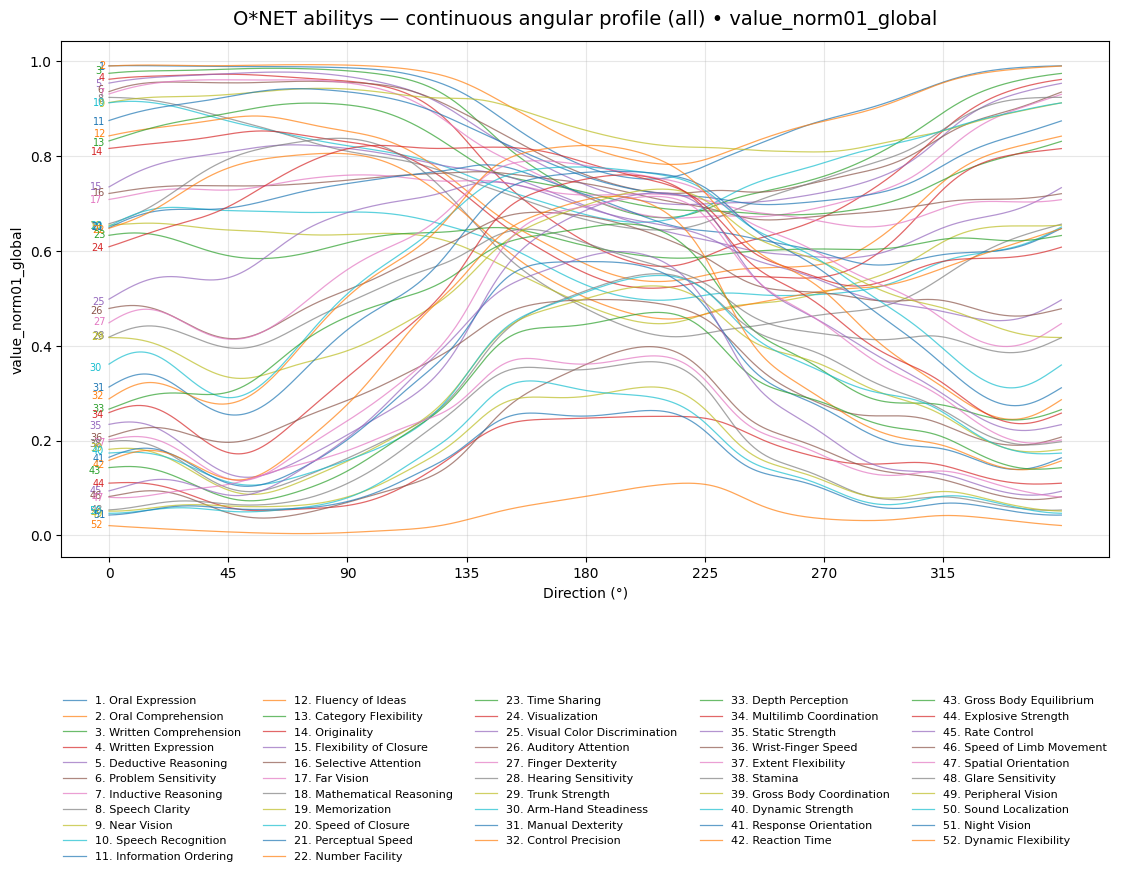

In [17]:
# === Cell: Continuous angular profiles from overlay long (infra RP + optional plot) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from infra import RP

label = "ability"        # "skill" | "ability"
use_col = "value_norm01_global"  # "value" | "value_norm01" | "value_norm01_global" | intensity cols too
zone = "all"           # "all" | "inner" | "outer"
kappa = 16.0
N = 720
seed = 42

# --- Load long export (new naming) ---
# expected: {label}s_overlay__{table}__{scale}__long.csv
pattern = f"{label}s_overlay__*__long.csv"
long_fp = sorted(RP.exports.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
if not long_fp:
    raise FileNotFoundError(f"No match for {pattern} in {RP.exports}")
long_fp = long_fp[0]

df = pd.read_csv(long_fp)

need = {"xi", "chi", label, use_col}
miss = need - set(df.columns)
if miss:
    raise ValueError(f"Missing columns in long file: {sorted(miss)}")

# --- Zone filter ---
chi_med = float(np.nanmedian(df["chi"].to_numpy(float)))
if zone == "outer":
    sub = df[df["chi"] >= chi_med].copy()
elif zone == "inner":
    sub = df[df["chi"] < chi_med].copy()
else:
    sub = df.copy()

names = sorted(sub[label].dropna().unique().tolist())
theta_grid = np.linspace(0, 2 * np.pi, N, endpoint=False)

def circ_reg(theta_s, y, theta_g, k):
    d = theta_g[:, None] - theta_s[None, :]
    K = np.exp(k * np.cos(d))  # von Mises kernel
    num = np.nansum(K * y[None, :], axis=1)
    den = np.nansum(K, axis=1)
    return np.divide(num, den, out=np.zeros_like(num), where=den > 0)

# --- Compute profiles ---
profiles = []
for n in names:
    m = sub[sub[label] == n]
    if m.empty:
        continue
    y = m[use_col].to_numpy(float)
    t = np.mod(m["xi"].to_numpy(float), 2 * np.pi)
    prof = circ_reg(t, y, theta_grid, kappa)
    profiles.append((n, prof))

# sort by start value at 0°
profiles.sort(key=lambda tup: float(tup[1][0]), reverse=True)

# --- Plot (optional) ---
DO_PLOT = True
if DO_PLOT:
    plt.figure(figsize=(12, 10))
    rng = np.random.default_rng(seed)

    lines, labels = [], []
    xdeg = np.degrees(theta_grid)

    for i, (n, prof) in enumerate(profiles, start=1):
        line, = plt.plot(xdeg, prof, lw=0.9, alpha=0.7, label=f"{i}. {n}")
        lines.append(line)
        labels.append(f"{i}. {n}")

        # numbering near 0° with jitter
        start_x = 0.0
        start_y = float(prof[0])
        x_jitter = float(rng.uniform(-3, -1))
        y_span = float(np.nanmax(prof) - np.nanmin(prof))
        y_jitter = float(rng.uniform(-0.02, 0.02) * y_span) if np.isfinite(y_span) else 0.0

        plt.text(start_x + x_jitter, start_y + y_jitter, str(i),
                 ha="right", va="center", fontsize=7, color=line.get_color())

    plt.title(f"O*NET {label}s — continuous angular profile ({zone}) • {use_col}", fontsize=14, pad=12)
    plt.xlabel("Direction (°)")
    plt.ylabel(use_col)
    plt.xticks(np.arange(0, 360, 45))
    plt.grid(alpha=0.3)

    plt.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, -0.25),
               ncol=5, fontsize=8, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 1])

    out_png = RP.figures / f"{label}s_profile__{zone}.png"
    out_pdf = RP.figures / f"{label}s_profile__{zone}.pdf"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
    plt.show()



=== KLUSTER-SUMMARY ===
group    type  n  R_mean  R_med  R_max  theta_mean
   A1 Ability 20   0.605  0.655  0.753      49.176
   A2 Ability 32   0.522  0.529  0.726     183.136
   S1   Skill 27   0.653  0.683  0.769      42.234
   S2   Skill  8   0.674  0.688  0.774     164.041

=== KLUSTER-INNEHÅLL (sorterat på resultant_R) ===

[A1]  n=20
  Oral Expression                           R=0.753  θ=21.1°  (Ability)
  Speech Clarity                            R=0.744  θ=3.5°  (Ability)
  Oral Comprehension                        R=0.729  θ=27.5°  (Ability)
  Written Expression                        R=0.721  θ=25.3°  (Ability)
  Written Comprehension                     R=0.704  θ=29.2°  (Ability)
  Inductive Reasoning                       R=0.703  θ=34.2°  (Ability)
  Deductive Reasoning                       R=0.698  θ=36.7°  (Ability)
  Speech Recognition                        R=0.692  θ=4.3°  (Ability)
  Fluency of Ideas                          R=0.678  θ=32.2°  (Ability)
  Category

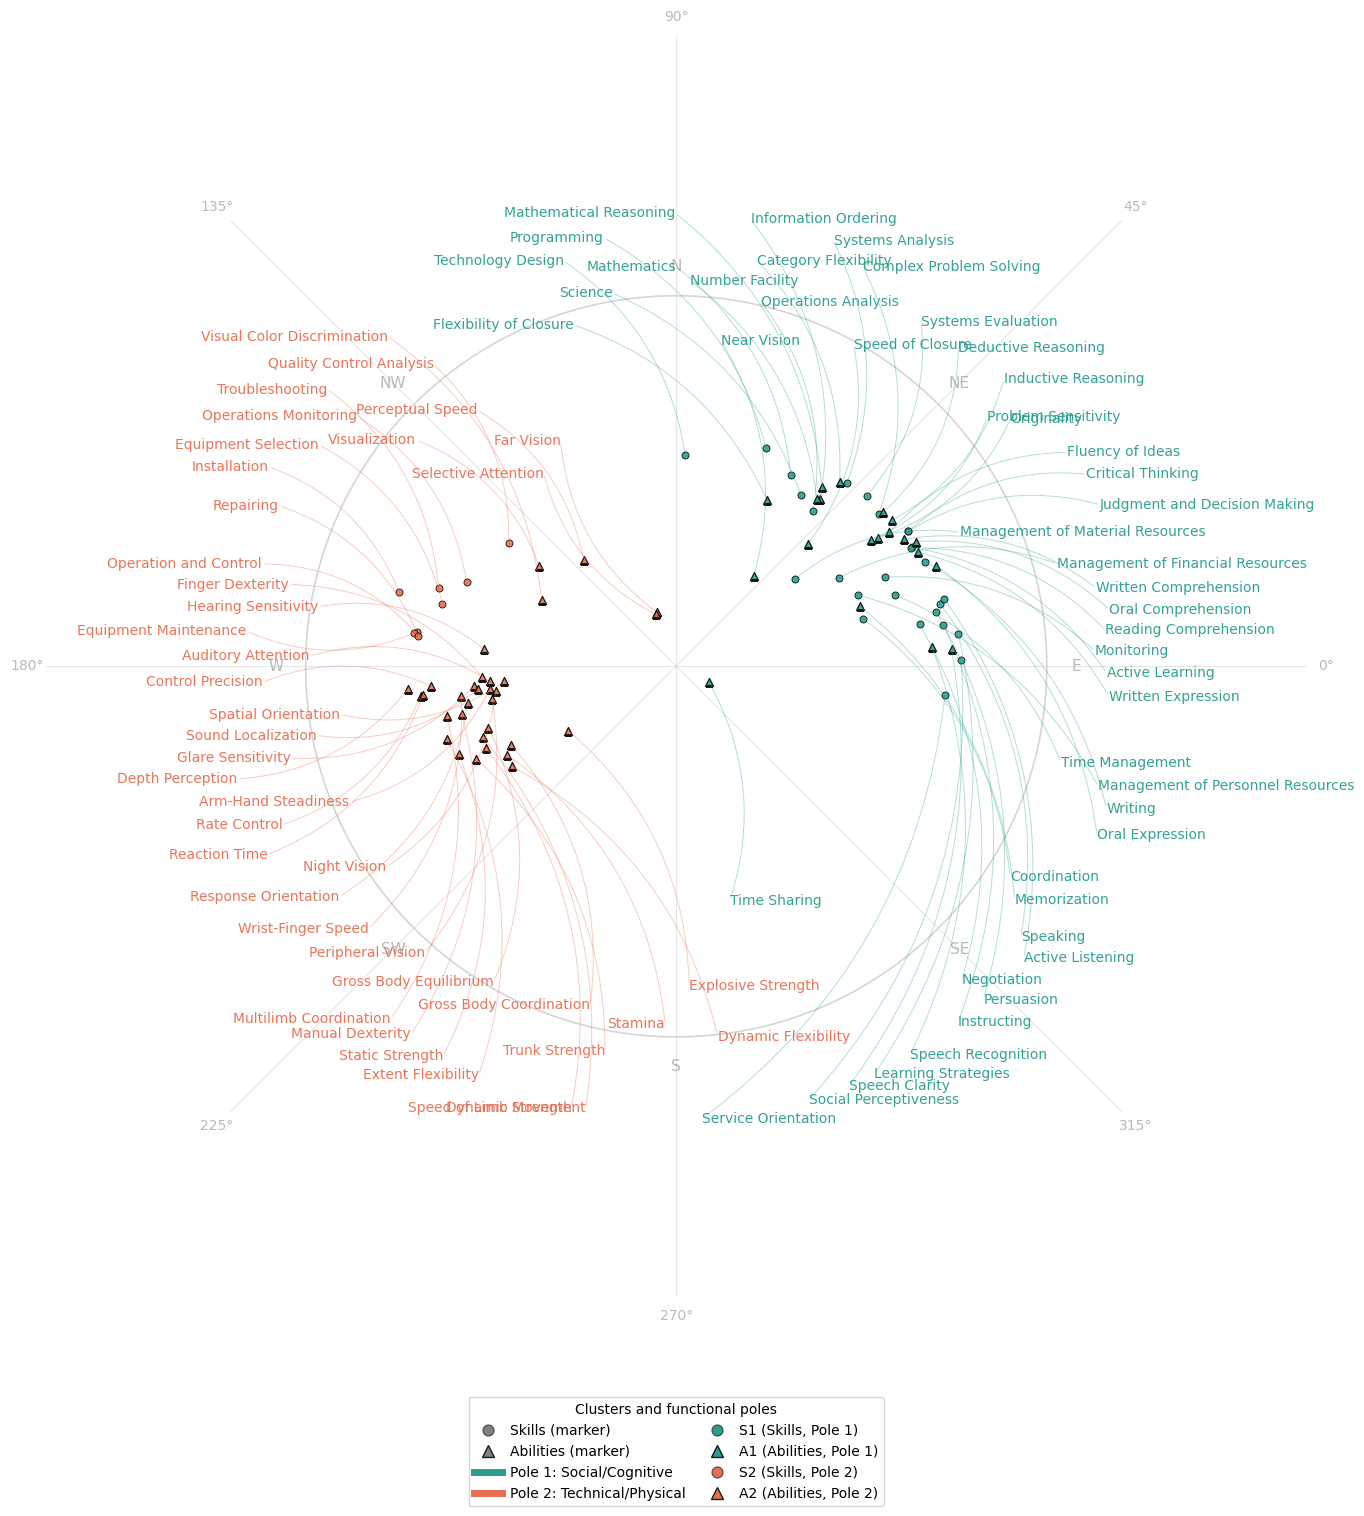

In [18]:
# === Cell: Gradientkompass med 4 kluster (S1/S2/A1/A2) + nya domäner (Pole 1/2) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from infra import RP, log
from plotutils import place_polar_labels_no_overlap_fast2

# ------------------------------------------------------------
# 0) Ladda senaste angle-rank (som tidigare)
# ------------------------------------------------------------
def load_latest_angle_rank(label: str) -> pd.DataFrame:
    angle_fp = _find_angle_rank_file(label)  # <-- din befintliga helper
    df = pd.read_csv(angle_fp)

    name_col = label
    required = {name_col, "theta_max_deg", "resultant_R"}
    miss = required - set(df.columns)
    if miss:
        raise ValueError(f"Saknar kolumner i {angle_fp.name}: {miss}")

    df = df.copy()
    df["theta_max_deg"] = pd.to_numeric(df["theta_max_deg"], errors="coerce")
    df["resultant_R"] = pd.to_numeric(df["resultant_R"], errors="coerce")
    df = df.dropna(subset=["theta_max_deg", "resultant_R"])

    df["type"] = "Skill" if label == "skill" else "Ability"
    df["name"] = df[name_col].astype(str)
    return df

def select_top(df, n):
    if n is None or n >= len(df):
        return df
    return df.sort_values("resultant_R", ascending=False).head(n)

def _wrap_deg(d):
    return float(d) % 360.0

def quadrant(theta_deg):
    """
    0=E, 90=N, 180=W, 270=S.
    Q1: 0..45
    Q2: 45..90
    Q3: 90..180
    Q4: 180..270
    270..360 -> Q1 (för att hålla E-klustret samman)
    """
    d = _wrap_deg(theta_deg)
    if 0.0 <= d < 45.0:
        return "Q1"
    if 45.0 <= d < 90.0:
        return "Q2"
    if 90.0 <= d < 180.0:
        return "Q3"
    if 180.0 <= d < 270.0:
        return "Q4"
    return "Q1"

def assign_group(row):
    q = quadrant(row["theta_max_deg"])
    if row["type"] == "Skill":
        return "S1" if q in ("Q1", "Q2") else "S2"
    else:
        return "A1" if q in ("Q1", "Q2") else "A2"

# ------------------------------------------------------------
# 1) Nya domäner: två poler (konceptuella domäner)
# ------------------------------------------------------------
POLE_LABEL = {
    "S1": "Pole 1: Social/Cognitive",
    "A1": "Pole 1: Social/Cognitive",
    "S2": "Pole 2: Technical/Physical",
    "A2": "Pole 2: Technical/Physical",
}

def pole_of_group(g: str) -> str:
    return POLE_LABEL.get(g, "UNASSIGNED")

# ------------------------------------------------------------
# 2) Load + cluster
# ------------------------------------------------------------
skills_df = load_latest_angle_rank("skill")
abilities_df = load_latest_angle_rank("ability")

n_skills = None
n_abilities = None
top_skills = select_top(skills_df, n_skills)
top_abilities = select_top(abilities_df, n_abilities)

df = pd.concat([top_skills, top_abilities], ignore_index=True)
df["group"] = df.apply(assign_group, axis=1)
df["pole"] = df["group"].map(pole_of_group)

# ------------------------------------------------------------
# 3) Summary + membership dump
# ------------------------------------------------------------
summary = (
    df.groupby(["group", "type"], as_index=False)
      .agg(
          n=("name", "size"),
          R_mean=("resultant_R", "mean"),
          R_med=("resultant_R", "median"),
          R_max=("resultant_R", "max"),
          theta_mean=("theta_max_deg", "mean"),
      )
      .sort_values(["type", "group"])
)

print("\n=== KLUSTER-SUMMARY ===")
print(summary.to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

print("\n=== KLUSTER-INNEHÅLL (sorterat på resultant_R) ===")
for g, dfg in df.sort_values("resultant_R", ascending=False).groupby("group"):
    print(f"\n[{g}]  n={len(dfg)}")
    for _, r0 in dfg.iterrows():
        print(f"  {r0['name']:<40}  R={r0['resultant_R']:0.3f}  θ={r0['theta_max_deg']:0.1f}°  ({r0['type']})")

clusters_fp = RP.export_fp("gradient_compass_4clusters_membership.csv")
df.sort_values(["group", "type", "resultant_R"], ascending=[True, True, False]).to_csv(clusters_fp, index=False)
log(f"Sparad klusterlista: {clusters_fp}")

# ------------------------------------------------------------
# 4) Styling: tydligare separation men tematiskt lika
#    - Pole 1 (Social/Cognitive): blå-grön familj
#    - Pole 2 (Technical/Physical): orange-röd familj
#    - Skills vs Abilities: marker (o vs ^) + edge/alpha
#    - S1/A1 delar hue; S2/A2 delar hue
# ------------------------------------------------------------
COLORS = {
    "S1": "#2a9d8f",  # Pole 1, skill (teal)
    "A1": "#2a9d8f",  # Pole 1, ability (samma hue)
    "S2": "#e76f51",  # Pole 2, skill (orange-red)
    "A2": "#e76f51",  # Pole 2, ability (samma hue)
}
MARKERS = {"Skill": "o", "Ability": "^"}

# små variationer som skiljer S/A inom samma pole utan att byta tema
EDGE = {"Skill": (0, 0, 0, 0.55), "Ability": (0, 0, 0, 0.85)}
LW   = {"Skill": 0.6, "Ability": 0.9}
SIZE = {"Skill": 26, "Ability": 34}
ALPHA= {"Skill": 0.90, "Ability": 0.90}

df["color"] = df["group"].map(COLORS)

theta = np.deg2rad(df["theta_max_deg"].to_numpy(float))
r = df["resultant_R"].to_numpy(float)
labels = df["name"].tolist()

# ------------------------------------------------------------
# 5) Plot
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)

# Fill the figure canvas (remove default subplot padding)
fig.subplots_adjust(left=0.02, right=0.98, bottom=0., top=0.98)
ax.set_position([0.02, 0.06, 0.96, 0.90])  # [x0, y0, width, height]

# sektor-etiketter (din befintliga sector_label-funktion)
for angle_deg in range(0, 360, 45):
    ax.text(np.deg2rad(angle_deg), 1.08, sector_label(angle_deg),
            ha="center", va="center", fontsize=11, color="gray", alpha=0.55)

# punkter: plotta per (group,type) för att få rätt marker/edge
for g in ["S1", "A1", "S2", "A2"]:
    sub = df[df["group"] == g]
    if sub.empty:
        continue
    typ = "Skill" if g.startswith("S") else "Ability"
    th = np.deg2rad(sub["theta_max_deg"].to_numpy(float))
    rr = sub["resultant_R"].to_numpy(float)

    ax.scatter(
        th, rr,
        s=SIZE[typ],
        c=COLORS[g],
        marker=MARKERS[typ],
        alpha=ALPHA[typ],
        linewidths=LW[typ],
        edgecolors=EDGE[typ],
        zorder=3,
    )

# labels (färg efter grupp, marker skill/ability syns i punkterna)
place_polar_labels_no_overlap_fast2(
    ax,
    theta_list=theta.tolist(),
    chi_list=r.tolist(),
    label_list=labels,
    base_offset=0.45,
    fontsize=10,
    min_sep_px=12,
    max_iter=180,
    step_r_px=7.0,
    step_t_px=4.0,
    init_jitter_px=8.0,
    outside_push_px=10.0,
    tangential_nudge_px=3.0,
    collision_jitter=0.35,
    safety_iters=18,
    leader_lw=0.7,
    leader_alpha=0.35,
    leader_curved=True,
    keep_inside_axes=False,
    force_outward=True,
    expand_rmax_if_needed=True,
    text_color=df["color"].tolist(),
    leader_color=df["color"].tolist(),
    text_alpha=0.95,
)

# prevent clipping
for t in ax.texts:
    t.set_clip_on(False)
for ln in ax.lines:
    ln.set_clip_on(False)

# ------------------------------------------------------------
# axis styling: hide outer perimeter, define "diagram perimeter" at r=1.0
# ------------------------------------------------------------
r_unit = 1.0
rmax   = 1.70          # label-halo (allows labels around ~1.5)
ax.set_ylim(0, rmax)

# Hide the *real* polar perimeter (which sits at r=rmax)
ax.spines["polar"].set_visible(False)   # strongest (no outer boundary at all)

# Optional: also remove the outer patch edge (rarely needed, but safe)
ax.patch.set_edgecolor("none")

# Draw our own "perimeter" at r=1.0
tt = np.linspace(0, 2*np.pi, 720)
ax.plot(
    tt,
    np.full_like(tt, r_unit),
    color="lightgray",
    alpha=0.95,
    linewidth=1.2,
    zorder=2,
)

# Grid/ticks
ax.set_yticks([])
ax.grid(True, color="lightgray", alpha=0.55, linestyle="-", linewidth=0.8)

ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
ax.set_xticklabels(
    ["0°","45°","90°","135°","180°","225°","270°","315°"],
    fontsize=10, color="gray", alpha=0.55
)

# ------------------------------------------------------------
# 6) Legend: separera "vad" (S/A) från "domän/pole" (1/2)
# ------------------------------------------------------------
legend_elements = [
    # type encoding
    Line2D([0],[0], marker="o", linestyle="none", color="none",
           markerfacecolor="gray", markeredgecolor=(0,0,0,0.6), markeredgewidth=0.8,
           markersize=8, label="Skills (marker)"),
    Line2D([0],[0], marker="^", linestyle="none", color="none",
           markerfacecolor="gray", markeredgecolor=(0,0,0,0.85), markeredgewidth=1.0,
           markersize=9, label="Abilities (marker)"),

    # pole / domain encoding
    Line2D([0],[0], color=COLORS["S1"], lw=5, label="Pole 1: Social/Cognitive"),
    Line2D([0],[0], color=COLORS["S2"], lw=5, label="Pole 2: Technical/Physical"),

    # group labels (kort, utan gamla begrepp)
    Line2D([0],[0], marker="o", linestyle="none", color="none",
           markerfacecolor=COLORS["S1"], markeredgecolor=(0,0,0,0.6), markeredgewidth=0.8,
           markersize=8, label="S1 (Skills, Pole 1)"),
    Line2D([0],[0], marker="^", linestyle="none", color="none",
           markerfacecolor=COLORS["A1"], markeredgecolor=(0,0,0,0.85), markeredgewidth=1.0,
           markersize=9, label="A1 (Abilities, Pole 1)"),
    Line2D([0],[0], marker="o", linestyle="none", color="none",
           markerfacecolor=COLORS["S2"], markeredgecolor=(0,0,0,0.6), markeredgewidth=0.8,
           markersize=8, label="S2 (Skills, Pole 2)"),
    Line2D([0],[0], marker="^", linestyle="none", color="none",
           markerfacecolor=COLORS["A2"], markeredgecolor=(0,0,0,0.85), markeredgewidth=1.0,
           markersize=9, label="A2 (Abilities, Pole 2)"),
]

leg = ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fontsize=10,
    frameon=True,
    title="Clusters and functional poles",
    borderaxespad=0.0,
    handletextpad=0.6,
    columnspacing=1.2,
)
#fig.subplots_adjust(bottom=0.14)

run_name = RP.run_dir.name if hasattr(RP, "run_dir") else "current run"
#plt.title(
#    "Skills & Abilities (4 clusters via peak direction)\n"
#    "Color encodes functional pole; marker encodes descriptor type; labels are no-overlap\n"
#    f"Run: {run_name}",
#    pad=35, fontsize=14
#)

pdf_fp = RP.figure_fp("master_gradient_compass_4clusters.pdf")
png_fp = RP.figure_fp("master_gradient_compass_4clusters.png")
plt.savefig(pdf_fp, dpi=400, bbox_inches="tight")
plt.savefig(png_fp, dpi=400, bbox_inches="tight")
log(f"Sparad figur: {pdf_fp}")

plt.show()

In [19]:
# === Cell: Algoritmisk klustring av riktningar (cirkulär, viktad k-means) ===
import numpy as np
import pandas as pd

# Förutsätter att du redan har `df` med kolumner:
#   type ∈ {"Skill","Ability"}, theta_max_deg, resultant_R, name, group (regelbaserad S1/S2/A1/A2)

def _wrap_deg(d):
    return float(d) % 360.0

def _unit_xy(theta_deg):
    th = np.deg2rad(theta_deg)
    return np.cos(th), np.sin(th)

def weighted_kmeans(X, w=None, k=2, n_init=10, max_iter=200, tol=1e-7, seed=0):
    """
    Enkel viktad k-means för 2D (här enhetscirkeln). Ingen sklearn.
    X: (n,2)
    w: (n,) sample weights (t.ex. resultant_R)
    Return: labels (n,), centers (k,2)
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X, float)
    n = X.shape[0]
    if w is None:
        w = np.ones(n, float)
    else:
        w = np.asarray(w, float)
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)

    best_inertia = np.inf
    best = None

    # k-means++ (viktad) init
    def init_centers():
        centers = np.empty((k, 2), float)
        # första center: viktad slump
        p = w / (w.sum() + 1e-12)
        i0 = rng.choice(n, p=p)
        centers[0] = X[i0]

        # resterande via D^2
        for j in range(1, k):
            d2 = np.min(((X[:, None, :] - centers[None, :j, :]) ** 2).sum(axis=2), axis=1)
            # vikta med w så att starkare punkter påverkar init mer
            q = w * d2
            if q.sum() <= 0:
                ij = rng.integers(0, n)
            else:
                ij = rng.choice(n, p=q / q.sum())
            centers[j] = X[ij]
        return centers

    for run in range(n_init):
        centers = init_centers()

        for it in range(max_iter):
            # assign
            d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            labels = np.argmin(d2, axis=1)

            # update (viktade medel)
            new_centers = centers.copy()
            for j in range(k):
                m = labels == j
                ww = w[m]
                if ww.sum() > 0:
                    new_centers[j] = (X[m] * ww[:, None]).sum(axis=0) / ww.sum()
                else:
                    # tomt kluster: reinit till en punkt
                    new_centers[j] = X[rng.integers(0, n)]

            shift = np.max(np.abs(new_centers - centers))
            centers = new_centers
            if shift < tol:
                break

        # inertia (viktad SSE)
        d2 = ((X - centers[labels]) ** 2).sum(axis=1)
        inertia = (w * d2).sum()
        if inertia < best_inertia:
            best_inertia = inertia
            best = (labels.copy(), centers.copy())

    return best[0], best[1]

def circular_mean_deg(theta_deg, w):
    th = np.deg2rad(theta_deg)
    c = np.sum(w * np.cos(th))
    s = np.sum(w * np.sin(th))
    ang = np.rad2deg(np.arctan2(s, c)) % 360.0
    return ang

def map_clusters_by_majority(d, algo_label_col, target_labels):
    """
    Mappar algoritm-kluster (0..k-1) till target_labels (t.ex. ["S1","S2"])
    genom majoritetsröstning (viktad av resultant_R) mot d["group"].
    """
    mapping = {}
    used = set()
    # beräkna score per (algo_cluster, target_label)
    scores = {}
    for cl in sorted(d[algo_label_col].unique()):
        dd = d[d[algo_label_col] == cl]
        for tl in target_labels:
            m = dd["group"].eq(tl).to_numpy()
            scores[(cl, tl)] = float((dd.loc[m, "resultant_R"]).sum())

    # greedy: för varje cl, välj bästa tl som inte redan används
    for cl in sorted(d[algo_label_col].unique()):
        cand = sorted(target_labels, key=lambda tl: scores[(cl, tl)], reverse=True)
        for tl in cand:
            if tl not in used:
                mapping[cl] = tl
                used.add(tl)
                break
        if cl not in mapping:
            # fallback
            mapping[cl] = cand[0]
    return mapping

# --- Förbered data på enhetscirkeln ---
d0 = df.copy()
d0["theta_max_deg"] = d0["theta_max_deg"].map(_wrap_deg)
xy = np.array([_unit_xy(t) for t in d0["theta_max_deg"].to_numpy(float)])
d0["ux"] = xy[:, 0]
d0["uy"] = xy[:, 1]

# --- 1) Klustra SKILLS i två cirkulära kluster ---
dS = d0[d0["type"] == "Skill"].copy()
X = dS[["ux", "uy"]].to_numpy(float)
w = dS["resultant_R"].to_numpy(float)
labS, cenS = weighted_kmeans(X, w=w, k=2, n_init=20, seed=1)
dS["kmeans2"] = labS

# Mappa (0/1) -> (S1/S2) via majoritet mot din regelgrupp
mapS = map_clusters_by_majority(dS, "kmeans2", ["S1", "S2"])
dS["kmeans_group"] = dS["kmeans2"].map(mapS)

# --- 2) Klustra ABILITIES i två cirkulära kluster ---
dA = d0[d0["type"] == "Ability"].copy()
X = dA[["ux", "uy"]].to_numpy(float)
w = dA["resultant_R"].to_numpy(float)
labA, cenA = weighted_kmeans(X, w=w, k=2, n_init=20, seed=2)
dA["kmeans2"] = labA

mapA = map_clusters_by_majority(dA, "kmeans2", ["A1", "A2"])
dA["kmeans_group"] = dA["kmeans2"].map(mapA)

# --- Sammanställ och jämför ---
dK = pd.concat([dS, dA], ignore_index=True)

dK["match"] = dK["kmeans_group"].eq(dK["group"])
acc_unw = dK["match"].mean()

# viktad träffsäkerhet (vikt = resultant_R)
acc_w = (dK["match"].to_numpy(float) * dK["resultant_R"].to_numpy(float)).sum() / dK["resultant_R"].sum()

print("\n=== AGREEMENT (k-means på enhetscirkeln, 2 kluster per typ) ===")
print(f"Oviktad träffsäkerhet: {acc_unw*100:0.1f}%")
print(f"Viktad (resultant_R)  : {acc_w*100:0.1f}%")

print("\n=== CONFUSION (regel->kmeans_group) ===")
print(pd.crosstab(dK["group"], dK["kmeans_group"], margins=True))

# --- Diagnostik: klustercentra som vinkel (per typ) ---
def center_angle_deg(center):
    return float(np.rad2deg(np.arctan2(center[1], center[0])) % 360.0)

print("\n=== SKILL-centra (k=2) ===")
for j in range(cenS.shape[0]):
    print(f"  center {j}: angle={center_angle_deg(cenS[j]):0.1f}°  mapped->{mapS[j]}")

print("\n=== ABILITY-centra (k=2) ===")
for j in range(cenA.shape[0]):
    print(f"  center {j}: angle={center_angle_deg(cenA[j]):0.1f}°  mapped->{mapA[j]}")

# --- (valfritt) Visa avvikelser ---
bad = dK[~dK["match"]].sort_values("resultant_R", ascending=False)
print("\n=== AVVIKELSER (topp 20 på resultant_R) ===")
cols = ["type", "name", "theta_max_deg", "resultant_R", "group", "kmeans_group"]
print(bad[cols].head(20).to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

# Om du vill använda detta i din plott: ersätt df["group"] med dK["kmeans_group"] (join på name+type).


=== AGREEMENT (k-means på enhetscirkeln, 2 kluster per typ) ===
Oviktad träffsäkerhet: 98.9%
Viktad (resultant_R)  : 99.7%

=== CONFUSION (regel->kmeans_group) ===
kmeans_group  A1  A2  S1  S2  All
group                            
A1            20   0   0   0   20
A2             1  31   0   0   32
S1             0   0  27   0   27
S2             0   0   0   8    8
All           21  31  27   8   87

=== SKILL-centra (k=2) ===
  center 0: angle=27.2°  mapped->S1
  center 1: angle=164.8°  mapped->S2

=== ABILITY-centra (k=2) ===
  center 0: angle=33.2°  mapped->A1
  center 1: angle=188.7°  mapped->A2

=== AVVIKELSER (topp 20 på resultant_R) ===
   type       name  theta_max_deg  resultant_R group kmeans_group
Ability Far Vision        109.746        0.155    A2           A1


In [20]:
# === Cell: Cluster profiles by derivative-trend with stability under subsampling + typicality + band width ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

# ----------------------------
# Preconditions
# ----------------------------
if "profiles" not in globals() or not profiles:
    raise RuntimeError("profiles saknas eller är tom. Kör profilcellen först.")
if "theta_grid" not in globals():
    raise RuntimeError("theta_grid saknas. Kör profilcellen först.")
if "RP" not in globals():
    raise RuntimeError("RP saknas (infra).")

# ----------------------------
# 0) Pack profiles into matrix
# ----------------------------
names = [n for (n, _) in profiles]
P = np.vstack([prof for (_, prof) in profiles]).astype(float)   # (M, N)
M, N = P.shape
xdeg = np.degrees(theta_grid)

# ----------------------------
# 1) Circular derivative (central diff on circle)
# ----------------------------
dtheta = 2 * np.pi / N
D = (np.roll(P, -1, axis=1) - np.roll(P, +1, axis=1)) / (2.0 * dtheta)

DO_SMOOTH = True
SMOOTH_WIN = 9
if DO_SMOOTH and SMOOTH_WIN >= 3:
    k = SMOOTH_WIN // 2
    D = np.nanmean(np.stack([np.roll(D, s, axis=1) for s in range(-k, k + 1)], axis=0), axis=0)

# ----------------------------
# 2) Features (exactly as before)
# ----------------------------
def zscore_rows(X, eps=1e-12):
    mu = np.nanmean(X, axis=1, keepdims=True)
    sd = np.nanstd(X, axis=1, keepdims=True)
    return (X - mu) / np.maximum(sd, eps)

USE_DERIVATIVE = True
USE_LEVEL = False
LEVEL_WEIGHT = 0.35

Xd = zscore_rows(D) if USE_DERIVATIVE else None
if USE_LEVEL:
    Xp = zscore_rows(P)
    X = np.hstack([Xd, LEVEL_WEIGHT * Xp]) if USE_DERIVATIVE else Xp
else:
    X = Xd

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# ----------------------------
# 3) Choose K via stability under subsampling (ARI)
# ----------------------------
K_MIN = 2
K_MAX = min(20, M - 1)

# If you expect few large clusters, keep this >=5 (or higher).
MIN_CLUSTER_SIZE = 5
SUBSAMPLE_FRAC = 0.85
N_REPS = 40
SEED = 42

# Feasible K range given MIN_CLUSTER_SIZE
K_MAX_FEAS = min(K_MAX, M // MIN_CLUSTER_SIZE)
if K_MAX_FEAS < K_MIN:
    MIN_CLUSTER_SIZE = max(2, min(M // K_MIN, MIN_CLUSTER_SIZE))
    K_MAX_FEAS = min(K_MAX, M // MIN_CLUSTER_SIZE)

if K_MAX_FEAS < K_MIN:
    raise RuntimeError(f"Too few profiles for stability selection: M={M}, MIN_CLUSTER_SIZE={MIN_CLUSTER_SIZE}")

rng = np.random.default_rng(SEED)
idx_all = np.arange(M)

def fit_labels_on_subset(sub_idx, k):
    model = AgglomerativeClustering(n_clusters=k, metric="cosine", linkage="average")
    return model.fit_predict(X[sub_idx])

def ari_on_overlap(ref_labels_full, sub_labels, sub_idx):
    # Compare on overlap (subsample is overlap with full set).
    # ARI is permutation-invariant.
    if sub_idx.size < max(10, int(0.2 * M)):
        return None
    return adjusted_rand_score(ref_labels_full[sub_idx], sub_labels)

stability_rows = []
best = {"k": None, "ari_mean": -np.inf, "ari_std": None, "frag": None, "score": -np.inf}

for k in range(K_MIN, K_MAX_FEAS + 1):
    ref = AgglomerativeClustering(n_clusters=k, metric="cosine", linkage="average").fit_predict(X)
    ref_counts = np.bincount(ref, minlength=k)

    # Avoid K that fragments below required minimum size
    if ref_counts.min() < MIN_CLUSTER_SIZE:
        continue

    aris = []
    sub_n = int(np.floor(SUBSAMPLE_FRAC * M))
    for _ in range(N_REPS):
        sub_idx = rng.choice(idx_all, size=sub_n, replace=False)
        sub_lab = fit_labels_on_subset(sub_idx, k)
        s = ari_on_overlap(ref, sub_lab, sub_idx)
        if s is not None:
            aris.append(s)

    if len(aris) < max(10, N_REPS // 3):
        continue

    ari_mean = float(np.mean(aris))
    ari_std = float(np.std(aris))

    # Soft preference for less fragmentation (larger smallest cluster)
    frag = float(ref_counts.min() / MIN_CLUSTER_SIZE)  # >=1 good; higher = safer
    score = ari_mean - 0.05 * ari_std + 0.02 * np.log(frag)

    stability_rows.append((k, ari_mean, ari_std, frag, len(aris), score))

    if score > best["score"]:
        best.update({"k": k, "ari_mean": ari_mean, "ari_std": ari_std, "frag": frag, "score": score})

if best["k"] is None:
    raise RuntimeError(
        "No stable K found. Try lowering MIN_CLUSTER_SIZE or increasing K_MAX_FEAS / adjusting SUBSAMPLE_FRAC."
    )

K = int(best["k"])
print(f"Selected K={K} by subsampling stability: ARI mean={best['ari_mean']:.3f}, std={best['ari_std']:.3f}, frag={best['frag']:.2f}, M={M}")

stability_df = pd.DataFrame(
    stability_rows,
    columns=["k", "ari_mean", "ari_std", "frag_min_over_req", "n_valid", "score"]
).sort_values("k")

DO_PLOT_STABILITY = False
if DO_PLOT_STABILITY and not stability_df.empty:
    plt.figure(figsize=(7, 3))
    plt.plot(stability_df["k"], stability_df["ari_mean"], marker="o", lw=1.2)
    plt.xlabel("K")
    plt.ylabel("ARI (mean over subsamples)")
    plt.title(f"{label}s stability vs K ({zone}) • {use_col}")
    plt.grid(alpha=0.3)
    out_png = RP.figures / f"{label}s_profile_clusters__{zone}__{use_col}__stability_ari.png"
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()

# Fit final labels on full data
labels = AgglomerativeClustering(n_clusters=K, metric="cosine", linkage="average").fit_predict(X)

# ----------------------------
# 4) Members + sizes
# ----------------------------
members_df = pd.DataFrame({"name": names, "cluster": labels})
sizes = members_df["cluster"].value_counts().sort_index()
print("\nCluster sizes:")
print(sizes.to_string())

# ----------------------------
# 5) Bundles + stable ordering + cluster_meta with band-width diagnostics
# ----------------------------
BAND_QLO = 0.20
BAND_QHI = 0.80
USE_MEDIAN = True

bundle_parts = []
cluster_rows = []

for c in range(K):
    idx = np.where(labels == c)[0]
    if idx.size == 0:
        continue

    Pc = P[idx, :]
    center = np.nanmedian(Pc, axis=0) if USE_MEDIAN else np.nanmean(Pc, axis=0)
    lo = np.nanquantile(Pc, BAND_QLO, axis=0)
    hi = np.nanquantile(Pc, BAND_QHI, axis=0)

    # stable order key
    sort_key = float(np.nanmedian(center))

    # band-width diagnostics (interpretation of "stråkets bredd")
    band = hi - lo
    band_mean = float(np.nanmean(band))
    band_p90 = float(np.nanquantile(band, 0.90))
    band_max = float(np.nanmax(band))

    cluster_rows.append((c, sort_key, int(idx.size), band_mean, band_p90, band_max))

    bundle_parts.append(pd.DataFrame({
        "cluster": c,
        "theta": theta_grid.astype(float),
        "deg": xdeg.astype(float),
        "center": center.astype(float),
        "lo": lo.astype(float),
        "hi": hi.astype(float),
    }))

bundle_df = pd.concat(bundle_parts, ignore_index=True)

# rank clusters by sort_key descending
cluster_order = sorted(cluster_rows, key=lambda t: t[1], reverse=True)
cluster_rank = {c: i + 1 for i, (c, *_rest) in enumerate(cluster_order)}

bundle_df["cluster_rank"] = bundle_df["cluster"].map(cluster_rank).astype(int)
members_df["cluster_rank"] = members_df["cluster"].map(cluster_rank).astype(int)

cluster_meta = pd.DataFrame(
    cluster_order,
    columns=["cluster", "center_median", "n", "band_mean", "band_p90", "band_max"]
)
cluster_meta["cluster_rank"] = cluster_meta["cluster"].map(cluster_rank).astype(int)
cluster_meta = cluster_meta.sort_values("cluster_rank").reset_index(drop=True)

members_df = members_df.sort_values(["cluster_rank", "name"]).reset_index(drop=True)

print("\nCluster band-width diagnostics (hi-lo over θ):")
print(cluster_meta[["cluster_rank", "cluster", "n", "band_mean", "band_p90", "band_max"]].to_string(index=False))

# ----------------------------
# 6) Typicality (ranked) + alphabetical listing (integrated)
# ----------------------------
def cosine_sim_rows_to_vec(Xrows, v, eps=1e-12):
    num = Xrows @ v
    den = (np.linalg.norm(Xrows, axis=1) * np.linalg.norm(v) + eps)
    return num / den

# Use derivative feature space used for clustering
Xd_full = zscore_rows(D)
Xd_full = np.nan_to_num(Xd_full, nan=0.0, posinf=0.0, neginf=0.0)

TOP_N_TYPICAL = 10
PRINT_MAX_ALPHA = 9999  # set lower if needed

typ_rows = []
cluster_typical = {}

for c, *_ in cluster_order:
    idx = np.where(labels == c)[0]
    if idx.size == 0:
        continue

    v = np.nanmedian(Xd_full[idx, :], axis=0)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)

    sims = cosine_sim_rows_to_vec(Xd_full[idx, :], v)
    pairs = list(zip([names[i] for i in idx], sims.tolist()))
    pairs.sort(key=lambda t: t[1], reverse=True)

    cluster_typical[c] = pairs
    for nm, sim in pairs:
        typ_rows.append((nm, c, cluster_rank[c], float(sim)))

typicality_df = pd.DataFrame(typ_rows, columns=["name", "cluster", "cluster_rank", "typicality_cos"])

# merge onto members_df
members_df = members_df.merge(typicality_df[["name", "typicality_cos"]], on="name", how="left")

print("\nNames per cluster: top-typical first, then alphabetical\n")
for c, *_ in cluster_order:
    cr = cluster_rank[c]
    sub = members_df[members_df["cluster"] == c].copy().sort_values("name")
    top = cluster_typical.get(c, [])[:TOP_N_TYPICAL]

    print(f"C{cr} (cluster={c}, n={len(sub)}):")
    print("  Top-typical (cosine to derivative-center):")
    for nm, sim in top:
        print(f"    - {nm}  (sim={sim:.3f})")
    print("  Alphabetical (all):")
    for nm in sub["name"].tolist()[:PRINT_MAX_ALPHA]:
        print("    -", nm)
    print()

# Write text report
out_names_typ = RP.exports / f"{label}s_profile_clusters__{zone}__{use_col}__K{K}__names_typical.txt"
with open(out_names_typ, "w", encoding="utf-8") as f:
    for c, *_ in cluster_order:
        cr = cluster_rank[c]
        sub = members_df[members_df["cluster"] == c].copy().sort_values("name")
        top = cluster_typical.get(c, [])[:TOP_N_TYPICAL]

        f.write(f"C{cr} (cluster={c}, n={len(sub)}):\n")
        f.write("  Band width meaning: hi-lo is dispersion in level at each θ; narrower = more homogeneous, wider = more heterogeneous.\n")
        f.write("  Top-typical (cosine to derivative-center):\n")
        for nm, sim in top:
            f.write(f"    - {nm}  (sim={sim:.3f})\n")
        f.write("  Alphabetical (all):\n")
        for nm in sub["name"].tolist():
            f.write(f"    - {nm}\n")
        f.write("\n")
print("Wrote:", out_names_typ)

# ----------------------------
# 8) Exports (all artifacts in one place)
# ----------------------------
out_members   = RP.exports / f"{label}s_profile_clusters__{zone}__{use_col}__K{K}__members.csv"
out_bundles   = RP.exports / f"{label}s_profile_clusters__{zone}__{use_col}__K{K}__bundles.csv"
out_meta      = RP.exports / f"{label}s_profile_clusters__{zone}__{use_col}__K{K}__meta.csv"
out_stability = RP.exports / f"{label}s_profile_clusters__{zone}__{use_col}__stability_ari.csv"
out_typ       = RP.exports / f"{label}s_profile_clusters__{zone}__{use_col}__K{K}__typicality.csv"

members_df.to_csv(out_members, index=False)
bundle_df.to_csv(out_bundles, index=False)
cluster_meta.to_csv(out_meta, index=False)
stability_df.to_csv(out_stability, index=False)
typicality_df.to_csv(out_typ, index=False)

print("\nWrote:")
print(" ", out_members)
print(" ", out_bundles)
print(" ", out_meta)
print(" ", out_stability)
print(" ", out_typ)
print(" ", out_names_typ)


Selected K=2 by subsampling stability: ARI mean=0.938, std=0.124, frag=4.00, M=52

Cluster sizes:
cluster
0    20
1    32

Cluster band-width diagnostics (hi-lo over θ):
 cluster_rank  cluster  n  band_mean  band_p90  band_max
            1        0 20   0.209536  0.278319  0.299612
            2        1 32   0.372721  0.407447  0.430925

Names per cluster: top-typical first, then alphabetical

C1 (cluster=0, n=20):
  Top-typical (cosine to derivative-center):
    - Deductive Reasoning  (sim=0.983)
    - Written Expression  (sim=0.981)
    - Problem Sensitivity  (sim=0.981)
    - Written Comprehension  (sim=0.979)
    - Inductive Reasoning  (sim=0.974)
    - Fluency of Ideas  (sim=0.969)
    - Originality  (sim=0.956)
    - Information Ordering  (sim=0.934)
    - Memorization  (sim=0.921)
    - Oral Comprehension  (sim=0.911)
  Alphabetical (all):
    - Category Flexibility
    - Deductive Reasoning
    - Flexibility of Closure
    - Fluency of Ideas
    - Inductive Reasoning
    - In

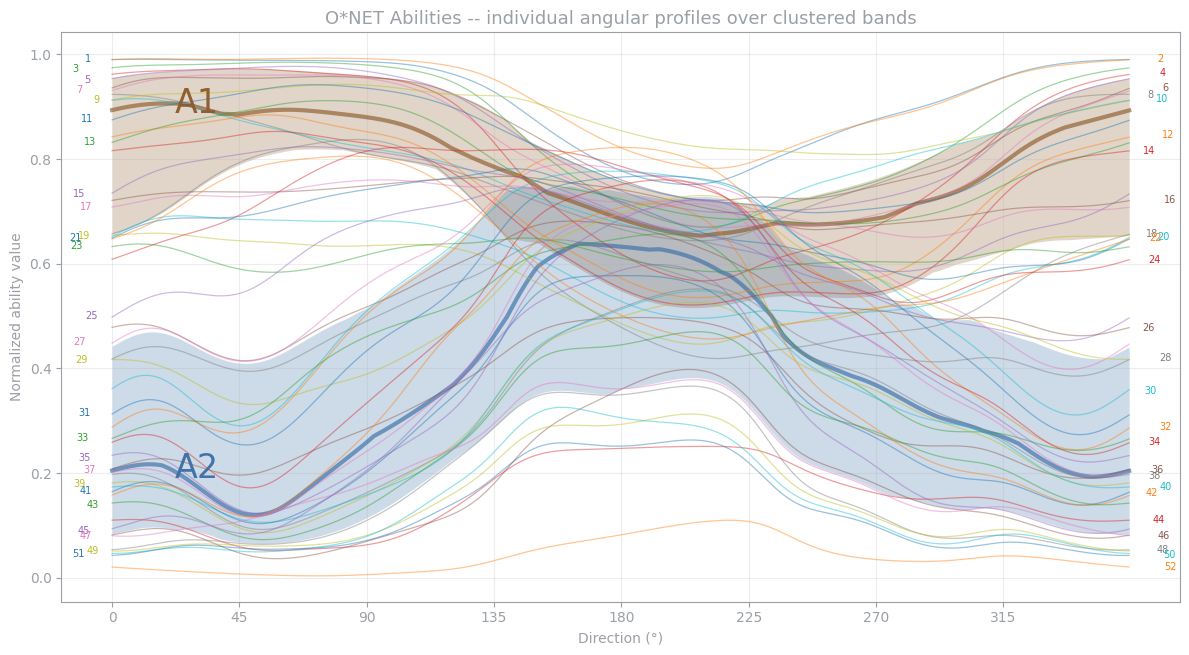

Wrote:
  /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/abilitys_profiles_over_bands__all__value_norm01_global.png
  /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/abilitys_profiles_over_bands__all__value_norm01_global.pdf


In [21]:
# === Cell: Overlay individual profiles on cluster bundles (bands semi-transparent) ===

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Preconditions
# ----------------------------
req = ["profiles", "theta_grid", "bundle_df", "cluster_order", "cluster_rank", "RP"]
missing = [k for k in req if k not in globals()]
if missing:
    raise RuntimeError(f"Missing globals {missing}. Run the profile + clustering cells first.")

# ----------------------------
# Controls
# ----------------------------
FIGSIZE = (12, 7)

# Bands (bundles)
BAND_ALPHA = 0.25
BAND_LINE_ALPHA = 0.65
BAND_LINE_LW = 3.0

# Individual lines
LINE_ALPHA = 0.45
LINE_LW = 0.9

MAX_LINES = None

ANNOTATE = True
ANNOTATE_FONTSIZE = 7
ANNOTATE_JITTER_DEG = 8.0

SHOW_LEGEND = False

# Axes/frame styling
AX_GREY = "#9AA0A6"         # light-ish grey for spines/ticks/labels
GRID_GREY_ALPHA = 0.22

# ----------------------------
# Discrete band palette: blue + brown family (damped, distinguishable)
# ----------------------------
BAND_PALETTE = [
    "#8B5A2B",  # sienna (brown)
    "#3A6EA5",  # steel-blue
    "#6B4F3A",  # umber (brown)
    "#4C566A",  # slate (blue-grey)
    "#7C6F64",  # taupe (brown-grey)
    "#2F4F4F",  # deep teal-grey
    "#5E4B3C",  # coffee brown
    "#3E5870",  # muted steel blue
    "#7A5A3A",  # warm brown
    "#334B5E",  # deep muted blue
    "#6A5C50",  # brownish grey
    "#3F4E5A",  # dark blue-grey
]

# ----------------------------
# Data prep
# ----------------------------
xdeg = np.degrees(theta_grid)

names = [n for (n, _) in profiles]
P = np.vstack([p for (_, p) in profiles]).astype(float)

if MAX_LINES is not None and P.shape[0] > MAX_LINES:
    names = names[:MAX_LINES]
    P = P[:MAX_LINES, :]

_label   = globals().get("label", "skill")
_zone    = globals().get("zone", "all")
_use_col = globals().get("use_col", "value_norm01_global")

# Labelname for title
if _label == "skill":
    labelname = "Skills"
    band_prefix = "S"
elif _label == "ability":
    labelname = "Abilities"
    band_prefix = "A"
else:
    labelname = f"{_label}s"
    band_prefix = _label[:1].upper()

# Map cluster -> color (ordered by cluster_order / rank)
cluster_ids = [c for (c, *_rest) in cluster_order]
band_color = {c: BAND_PALETTE[i % len(BAND_PALETTE)] for i, c in enumerate(cluster_ids)}

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

# 1) Plot bundles with palette colors + labels S1/S2... or A1/A2...
for c, *_ in cluster_order:
    cr = int(cluster_rank[c])  # rank gives stable ordering
    b = bundle_df[bundle_df["cluster"] == c].sort_values("deg")

    xx = b["deg"].to_numpy(float)
    center = b["center"].to_numpy(float)
    lo = b["lo"].to_numpy(float)
    hi = b["hi"].to_numpy(float)

    col = band_color[c]
    ax.fill_between(xx, lo, hi, alpha=BAND_ALPHA, linewidth=0, color=col)
    ax.plot(xx, center, lw=BAND_LINE_LW, alpha=BAND_LINE_ALPHA, color=col)

    # Band label: place near 20° (robust) with slight x-offset
    lab_x = 20.0
    j = int(np.argmin(np.abs(xx - lab_x)))
    ax.text(
        xx[j] + 2.0,
        center[j],
        f"{band_prefix}{cr}",
        color=col,
        fontsize=24,
        va="center",
        ha="left",
        alpha=0.95,
    )

# 2) Plot individual profiles (store line handles)
lines = []
for i in range(P.shape[0]):
    (ln,) = ax.plot(xdeg, P[i], lw=LINE_LW, alpha=LINE_ALPHA)
    lines.append(ln)

# 3) Annotate indices left/right, match line color
if ANNOTATE:
    rng = np.random.default_rng(42)

    for i, ln in enumerate(lines):
        y0 = float(P[i, 0])
        y_span = float(np.nanmax(P[i]) - np.nanmin(P[i]) + 1e-12)
        yj = float(rng.uniform(-1, 1)) * 0.01 * y_span
        col = ln.get_color()

        if i % 2 == 0:
            x0 = -float(rng.uniform(0.5, 1.5) * ANNOTATE_JITTER_DEG)
            ha = "right"
        else:
            x0 = 360.0 + float(rng.uniform(0.5, 1.5) * ANNOTATE_JITTER_DEG)
            ha = "left"

        ax.text(
            x0, y0 + yj, str(i + 1),
            ha=ha, va="center",
            fontsize=ANNOTATE_FONTSIZE,
            color=col
        )

# ----------------------------
# Cosmetics
# ----------------------------
ax.set_title(
    f"O*NET {labelname} -- individual angular profiles over clustered bands",
    fontsize=13,
    color=AX_GREY,
)
ax.set_xlabel("Direction (°)", color=AX_GREY)
ax.set_ylabel(f"Normalized {_label} value", color=AX_GREY)
ax.set_xticks(np.arange(0, 360, 45))
ax.grid(alpha=GRID_GREY_ALPHA)

# Light grey spines + ticks
for spine in ax.spines.values():
    spine.set_color(AX_GREY)
ax.tick_params(axis="both", colors=AX_GREY)

if SHOW_LEGEND:
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=6, frameon=False)

fig.tight_layout(rect=[0, 0.05, 1, 1])

# ----------------------------
# Save
# ----------------------------
out_base = f"{_label}s_profiles_over_bands__{_zone}__{_use_col}"
out_png = RP.figures / f"{out_base}.png"
out_pdf = RP.figures / f"{out_base}.pdf"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.show()

print("Wrote:")
print(" ", out_png)
print(" ", out_pdf)


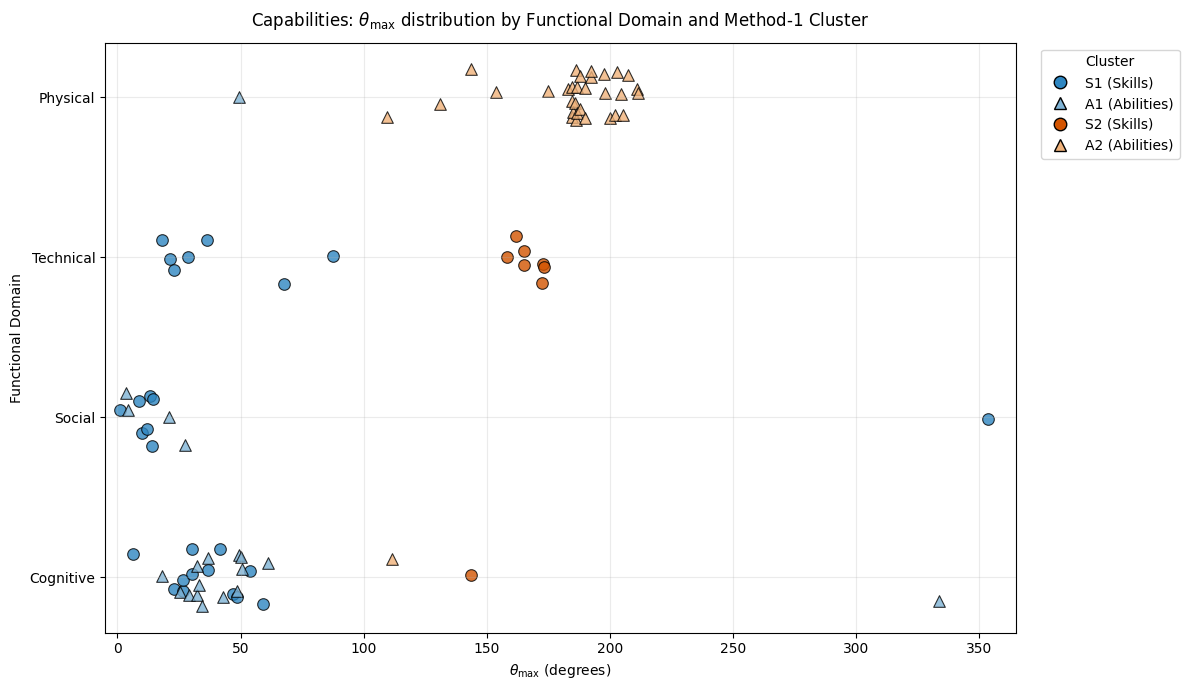

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# 0) Method-1 clusters (given)
# -----------------------------
A1 = {
    "Oral Expression","Speech Clarity","Oral Comprehension","Written Expression","Written Comprehension",
    "Inductive Reasoning","Deductive Reasoning","Speech Recognition","Fluency of Ideas","Category Flexibility",
    "Originality","Problem Sensitivity","Mathematical Reasoning","Information Ordering","Number Facility",
    "Memorization","Flexibility of Closure","Speed of Closure","Near Vision","Time Sharing"
}

A2 = {
    "Depth Perception","Rate Control","Reaction Time","Control Precision","Extent Flexibility",
    "Multilimb Coordination","Static Strength","Trunk Strength","Manual Dexterity","Wrist-Finger Speed",
    "Response Orientation","Dynamic Strength","Speed of Limb Movement","Glare Sensitivity","Sound Localization",
    "Gross Body Equilibrium","Finger Dexterity","Hearing Sensitivity","Dynamic Flexibility","Stamina",
    "Arm-Hand Steadiness","Auditory Attention","Peripheral Vision","Gross Body Coordination","Night Vision",
    "Spatial Orientation","Visualization","Visual Color Discrimination","Perceptual Speed","Explosive Strength",
    "Far Vision","Selective Attention"
}

S1 = {
    "Social Perceptiveness","Learning Strategies","Active Listening","Speaking","Service Orientation",
    "Instructing","Writing","Critical Thinking","Judgment and Decision Making","Persuasion",
    "Active Learning","Reading Comprehension","Systems Evaluation","Complex Problem Solving","Systems Analysis",
    "Negotiation","Programming","Time Management","Monitoring","Mathematics","Technology Design","Science",
    "Operations Analysis","Management of Personnel Resources","Coordination",
    "Management of Financial Resources","Management of Material Resources"
}

S2 = {
    "Installation","Equipment Maintenance","Repairing","Operation and Control","Troubleshooting",
    "Equipment Selection","Operations Monitoring","Quality Control Analysis"
}

def assign_cluster(capability: str, typ: str) -> str:
    if typ == "Skills":
        if capability in S1: return "S1"
        if capability in S2: return "S2"
    elif typ == "Abilities":
        if capability in A1: return "A1"
        if capability in A2: return "A2"
    return "UNASSIGNED"

def pole_of(cluster: str) -> str:
    if cluster in ("S1", "A1"):
        return "Pole 1 (Social/Cognitive)"
    if cluster in ("S2", "A2"):
        return "Pole 2 (Technical/Physical)"
    return "UNASSIGNED"

# -----------------------------
# 1) Old categories -> 4 domains
# -----------------------------
domain_mapping = {
    "symbolic": "Cognitive", "cognitive": "Cognitive", "analytical": "Cognitive",
    "communicative": "Social", "social": "Social",
    "operational": "Technical", "technical": "Technical",
    "perceptual": "Physical", "sensorimotor": "Physical",
}

# -----------------------------
# 2) Data (with your revisions)
#    - Coordination -> social
#    - Quality Control Analysis -> analytical
# -----------------------------
skills_raw = [
    ("Social Perceptiveness", 1.2, "social"),
    ("Learning Strategies", 6.5, "cognitive"),
    ("Instructing", 8.8, "communicative"),
    ("Negotiation", 9.8, "social"),
    ("Persuasion", 11.9, "communicative"),
    ("Speaking", 13.2, "communicative"),
    ("Active Listening", 14.1, "communicative"),
    ("Coordination", 14.3, "social"),                      # revised
    ("Time Management", 18.1, "operational"),
    ("Management of Personnel Resources", 21.3, "operational"),
    ("Writing", 22.8, "symbolic"),
    ("Monitoring", 23.0, "operational"),
    ("Active Learning", 26.8, "cognitive"),
    ("Reading Comprehension", 26.8, "symbolic"),
    ("Management of Financial Resources", 28.6, "operational"),
    ("Judgment and Decision Making", 30.2, "analytical"),
    ("Critical Thinking", 30.2, "analytical"),
    ("Management of Material Resources", 36.3, "operational"),
    ("Complex Problem Solving", 36.9, "analytical"),
    ("Systems Evaluation", 41.8, "analytical"),
    ("Systems Analysis", 47.1, "analytical"),
    ("Operations Analysis", 48.7, "analytical"),
    ("Science", 54.0, "analytical"),
    ("Mathematics", 59.0, "analytical"),
    ("Programming", 67.6, "technical"),
    ("Technology Design", 87.6, "technical"),
    ("Quality Control Analysis", 143.7, "analytical"),      # revised
    ("Operations Monitoring", 158.1, "operational"),
    ("Troubleshooting", 161.8, "technical"),
    ("Equipment Selection", 165.0, "technical"),
    ("Installation", 165.0, "technical"),
    ("Repairing", 172.5, "technical"),
    ("Equipment Maintenance", 172.8, "technical"),
    ("Operation and Control", 173.2, "operational"),
    ("Service Orientation", 353.8, "social"),
]

abilities_raw = [
    ("Speech Clarity", 3.5, "communicative"),
    ("Speech Recognition", 4.3, "communicative"),
    ("Memorization", 18.1, "cognitive"),
    ("Oral Expression", 21.1, "communicative"),
    ("Written Expression", 25.3, "symbolic"),
    ("Oral Comprehension", 27.5, "communicative"),
    ("Written Comprehension", 29.2, "symbolic"),
    ("Fluency of Ideas", 32.2, "cognitive"),
    ("Originality", 32.5, "cognitive"),
    ("Problem Sensitivity", 33.0, "analytical"),
    ("Inductive Reasoning", 34.2, "analytical"),
    ("Deductive Reasoning", 36.7, "analytical"),
    ("Speed of Closure", 42.9, "cognitive"),
    ("Category Flexibility", 48.5, "cognitive"),
    ("Information Ordering", 49.2, "cognitive"),
    ("Near Vision", 49.3, "perceptual"),
    ("Number Facility", 50.0, "analytical"),
    ("Mathematical Reasoning", 50.8, "analytical"),
    ("Flexibility of Closure", 61.3, "cognitive"),
    ("Far Vision", 109.7, "perceptual"),
    ("Selective Attention", 111.6, "cognitive"),
    ("Perceptual Speed", 131.0, "perceptual"),
    ("Visualization", 143.8, "perceptual"),
    ("Visual Color Discrimination", 153.7, "perceptual"),
    ("Hearing Sensitivity", 174.9, "perceptual"),
    ("Finger Dexterity", 183.1, "sensorimotor"),
    ("Auditory Attention", 184.6, "perceptual"),
    ("Control Precision", 184.7, "sensorimotor"),
    ("Depth Perception", 184.8, "perceptual"),
    ("Spatial Orientation", 184.9, "perceptual"),
    ("Glare Sensitivity", 185.7, "perceptual"),
    ("Sound Localization", 186.5, "perceptual"),
    ("Rate Control", 186.5, "sensorimotor"),
    ("Reaction Time", 186.6, "sensorimotor"),
    ("Arm-Hand Steadiness", 186.9, "sensorimotor"),
    ("Night Vision", 187.8, "perceptual"),
    ("Wrist-Finger Speed", 187.9, "sensorimotor"),
    ("Response Orientation", 190.0, "sensorimotor"),
    ("Peripheral Vision", 190.1, "perceptual"),
    ("Multilimb Coordination", 192.2, "sensorimotor"),
    ("Manual Dexterity", 192.4, "sensorimotor"),
    ("Extent Flexibility", 197.6, "sensorimotor"),
    ("Gross Body Equilibrium", 198.2, "sensorimotor"),
    ("Speed of Limb Movement", 200.2, "sensorimotor"),
    ("Static Strength", 202.0, "sensorimotor"),
    ("Dynamic Strength", 203.1, "sensorimotor"),
    ("Trunk Strength", 204.7, "sensorimotor"),
    ("Gross Body Coordination", 205.5, "sensorimotor"),
    ("Stamina", 207.6, "sensorimotor"),
    ("Explosive Strength", 210.9, "sensorimotor"),
    ("Dynamic Flexibility", 211.3, "sensorimotor"),
    ("Time Sharing", 333.9, "cognitive"),
]

df_s = pd.DataFrame(skills_raw, columns=["Capability", "theta", "OldCat"])
df_s["Type"] = "Skills"
df_a = pd.DataFrame(abilities_raw, columns=["Capability", "theta", "OldCat"])
df_a["Type"] = "Abilities"
df = pd.concat([df_s, df_a], ignore_index=True)

df["Domain"] = df["OldCat"].map(domain_mapping)
df["Cluster"] = [assign_cluster(c, t) for c, t in zip(df["Capability"], df["Type"])]
df["Pole"] = df["Cluster"].map(pole_of)

# -----------------------------
# 2b) Sanity checks
# -----------------------------
if df["Domain"].isna().any():
    bad = sorted(df.loc[df["Domain"].isna(), "OldCat"].unique().tolist())
    raise ValueError(f"Unmapped OldCat values: {bad}")

unassigned = df[df["Cluster"] == "UNASSIGNED"][["Type", "Capability"]]
if not unassigned.empty:
    raise ValueError("UNASSIGNED capabilities (check spelling/sets):\n" + unassigned.to_string(index=False))

expected = {("Skills", "S1"): 27, ("Skills", "S2"): 8, ("Abilities", "A1"): 20, ("Abilities", "A2"): 32}
counts = df.groupby(["Type", "Cluster"]).size().to_dict()
for k, v in expected.items():
    got = counts.get(k, 0)
    if got != v:
        raise ValueError(f"Cluster size mismatch for {k}: expected {v}, got {got}")

# -----------------------------
# 3) Plot (matplotlib; no seaborn)
# -----------------------------
domain_order = ["Cognitive", "Social", "Technical", "Physical"]
ypos = {d: i for i, d in enumerate(domain_order)}

# Thematic styling:
# - Same hue per pole, different shade per Type (Skills vs Abilities)
style = {
    "S1": dict(marker="o", face="#2E86C1", edge="black", label="S1 (Skills)"),
    "A1": dict(marker="^", face="#7FB3D5", edge="black", label="A1 (Abilities)"),
    "S2": dict(marker="o", face="#D35400", edge="black", label="S2 (Skills)"),
    "A2": dict(marker="^", face="#F0B27A", edge="black", label="A2 (Abilities)"),
}

rng = np.random.default_rng(7)  # deterministic jitter

fig, ax = plt.subplots(figsize=(12, 7))

for cl in ["S1", "A1", "S2", "A2"]:
    sub = df[df["Cluster"] == cl].copy()
    y = sub["Domain"].map(ypos).to_numpy(dtype=float)
    y = y + rng.uniform(-0.18, 0.18, size=len(y))  # vertical jitter
    ax.scatter(
        sub["theta"].to_numpy(),
        y,
        s=70,
        marker=style[cl]["marker"],
        facecolors=style[cl]["face"],
        edgecolors=style[cl]["edge"],
        linewidths=0.8,
        alpha=0.80,
        label=style[cl]["label"],
    )

ax.set_yticks([ypos[d] for d in domain_order])
ax.set_yticklabels(domain_order)
ax.set_xlabel(r"$\theta_{\max}$ (degrees)")
ax.set_ylabel("Functional Domain")
ax.set_title(r"Capabilities: $\theta_{\max}$ distribution by Functional Domain and Method-1 Cluster", pad=12)

# Nice x-limits for degrees
ax.set_xlim(-5, 365)

# Light grid
ax.grid(True, axis="both", alpha=0.25)

# Legend: cluster-level
handles = [
    Line2D([0],[0], marker=style["S1"]["marker"], color="w", label=style["S1"]["label"],
           markerfacecolor=style["S1"]["face"], markeredgecolor="black", markersize=9),
    Line2D([0],[0], marker=style["A1"]["marker"], color="w", label=style["A1"]["label"],
           markerfacecolor=style["A1"]["face"], markeredgecolor="black", markersize=9),
    Line2D([0],[0], marker=style["S2"]["marker"], color="w", label=style["S2"]["label"],
           markerfacecolor=style["S2"]["face"], markeredgecolor="black", markersize=9),
    Line2D([0],[0], marker=style["A2"]["marker"], color="w", label=style["A2"]["label"],
           markerfacecolor=style["A2"]["face"], markeredgecolor="black", markersize=9),
]
ax.legend(handles=handles, title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()